<a href="https://colab.research.google.com/github/faheema2006/MLOPS/blob/main/Task_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving factory_dataset_500.xlsx to factory_dataset_500.xlsx


In [ ]:
import pandas as pd
dataset = pd.read_excel('/content/factory_dataset_500.xlsx')
print(dataset.head())

    RPM  Vibration  Pressure  Temperature Machine_Mode  Defective
0  2992       5.28       107        65.83     Standard          1
1  2847       3.59       142        62.75   High-Speed          0
2  3093       1.46       140        60.85     Standard          0
3  1148       4.15       138        46.68     Standard          0
4  3659       1.12       101        63.88     Standard          0


In [ ]:
print(dataset.columns)
print(dataset.shape)

Index(['RPM', 'Vibration', 'Pressure', 'Temperature', 'Machine_Mode',
       'Defective'],
      dtype='object')
(500, 6)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
X = dataset[['RPM']]
y = dataset['Temperature']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
y_pred = simple_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 22.45565685099311


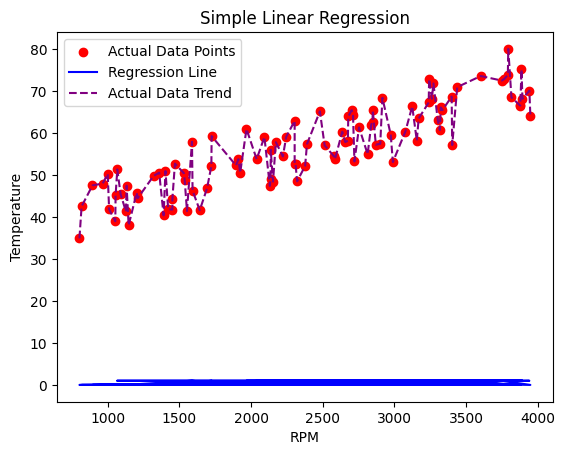

In [ ]:
import matplotlib.pyplot as plt
sorted_test_data = X_test.copy()
sorted_test_data['Temperature'] = dataset['Temperature'].loc[sorted_test_data.index]
sorted_test_data = sorted_test_data.sort_values(by='RPM')
plt.scatter(X_test['RPM'], dataset['Temperature'].loc[X_test.index], color='red', label='Actual Data Points')
plt.plot(X_test['RPM'], y_pred, color='blue', label='Regression Line')
plt.plot(sorted_test_data['RPM'], sorted_test_data['Temperature'], color='purple', linestyle='--', label='Actual Data Trend')
plt.xlabel('RPM')
plt.ylabel('Temperature')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [ ]:
X = dataset[['RPM','Vibration','Pressure']]
y = dataset['Temperature']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred = multi_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Multivariate Linear Regression MSE:", mse)

Multivariate Linear Regression MSE: 1.107333518989597e-26


In [ ]:
import joblib
joblib.dump(multi_model,'temperature_model.pkl')
print("Model Saved")

Model Saved


In [ ]:
loaded_model = joblib.load('temperature_model.pkl')
new_data = [[2500, 4.5, 120]]
prediction = loaded_model.predict(new_data)
print("Predicted Temperature:", prediction[0])

Predicted Temperature: 60.000000000000014


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
encoded_dataset = pd.get_dummies(dataset,columns=['Machine_Mode'],drop_first=True)
print(encoded_dataset.head())

    RPM  Vibration  Pressure  Temperature  Defective  Machine_Mode_High-Speed  \
0  2992       5.28       107        65.83          1                    False   
1  2847       3.59       142        62.75          0                     True   
2  3093       1.46       140        60.85          0                    False   
3  1148       4.15       138        46.68          0                    False   
4  3659       1.12       101        63.88          0                    False   

   Machine_Mode_Standard  
0                   True  
1                  False  
2                   True  
3                   True  
4                   True  


In [ ]:
X = encoded_dataset.drop(['Defective'],axis=1)
y = encoded_dataset['Defective']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(y_pred)

[0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0
 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[58  5]
 [ 7 30]]


In [ ]:
score = classifier.score(X_test,y_test)
print("Accuracy:", score)

Accuracy: 0.88


In [ ]:
new_machine = [[2500,4.5,120,58.2,1,0]]
result = classifier.predict(new_machine)
print(result)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
print("Simple Linear Regression MSE:", simple_mse)
print("Multivariate Linear Regression MSE:", multi_mse)

Simple Linear Regression MSE: 3279.1054933943046
Multivariate Linear Regression MSE: 3257.0175930000005


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.88


In [ ]:
joblib.dump(classifier,'defective_classifier.pkl')

['defective_classifier.pkl']

In [ ]:
loaded_classifier = joblib.load('defective_classifier.pkl')

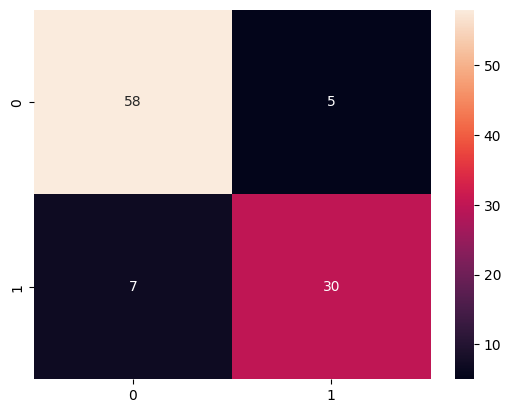

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True)
plt.show()